# **Informações sobre o dataset:**

Este conjunto de dados contém informações médicas e de estilo de vida de 1500 pacientes, projetado para prever a presença de câncer com base em diversas características. O conjunto de dados é estruturado para fornecer um desafio realista para a modelagem preditiva na área médica.


<br><br>


**Age:** Valores inteiros que representam a idade do paciente, variando de 20 a 80 anos.


**Gender:** Valores binários que representam o gênero, onde 0 indica Masculino e 1 indica Feminino.


**BMI:** Valores contínuos que representam o Índice de Massa Corporal (IMC), variando de 15 a 40.


**Smoking:** Valores binários que indicam se você fuma ou não, onde 0 significa Não e 1 significa Sim.


**GeneticRisk**: Valores categóricos que representam os níveis de risco genético para câncer, sendo 0 indicativo de baixo risco, 1 de risco médio e 2 de risco alto.


**PhysicalActivity**: Valores contínuos que representam o número de horas por semana dedicadas a atividades físicas, variando de 0 a 10.


**AlcoholIntake**: Valores contínuos que representam o número de unidades de álcool consumidas por semana, variando de 0 a 5.


**CancerHistory**: Valores binários que indicam se o paciente tem histórico pessoal de câncer, onde 0 significa Não e 1 significa Sim.


**Diagnosis**: Valores binários que indicam o status do diagnóstico de câncer, onde 0 indica Sem Câncer e 1 indica Câncer.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [32]:
df = pd.read_csv('cancer.csv')

In [33]:
df

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1
...,...,...,...,...,...,...,...,...,...
1495,62,1,25.090025,0,0,9.892167,1.284158,0,1
1496,31,0,33.447125,0,1,1.668297,2.280636,1,1
1497,63,1,32.613861,1,1,0.466848,0.150101,0,1
1498,55,0,25.568216,0,0,7.795317,1.986138,1,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


# **Análise Exploratória**

## 1. Quantas linhas e colunas possui o dataset? Existem nulos?

In [35]:
df.shape

(1500, 9)

## 2. Qual a idade mais frequente do conjunto de dados?

In [36]:
df['Age'].mode()

,Age
0,52


## 3. Qual a idade mais frequente dos pacientes que foram diagnosticados com câncer?

In [37]:
# Pega as idades das pessoas que têm câncer
idade_com_cancer = df.loc[df['Diagnosis'] == 1, 'Age'].mode()

# Mostra a segunda moda (se existir mais de uma)
print(idade_com_cancer.values[1])


66


## 4. Fumantes têm mais câncer que não fumantes?

In [38]:
# Cria uma tabela mostrando a proporção de câncer dentro de cada categoria de fumante
pd.crosstab(df['Smoking'], df['Diagnosis'], normalize='index')

Diagnosis,0,1
Smoking,,
0,0.695255,0.304745
1,0.448020,0.551980


## 5. Qual a proporção das classes da variável alvo? Tem mais pacientes diagnosticados com câncer ou sem câncer? As classes são desbalanceadas?

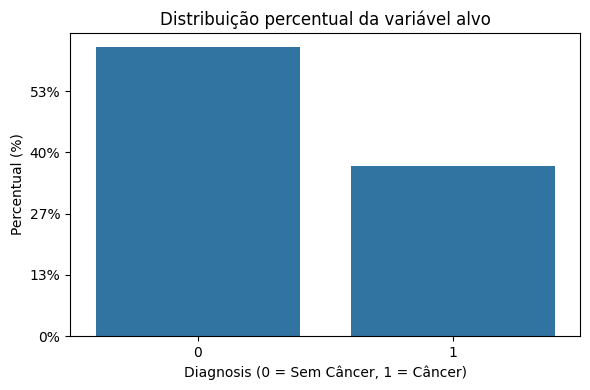

In [39]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(6,4))  # melhora a visualização

ax = sns.countplot(data=df, x='Diagnosis')

# Formata o eixo Y para percentual
ax.yaxis.set_major_formatter(PercentFormatter(xmax=df.shape[0]))

ax.set(
    xlabel='Diagnosis (0 = Sem Câncer, 1 = Câncer)',
    ylabel='Percentual (%)',
    title='Distribuição percentual da variável alvo'
)

plt.tight_layout()
plt.show()


## 6. Qual a distribuição das variáveis numéricas? Alguma delas apresenta distribuição normal? Ou todas são assimétricas?

               Age          BMI  PhysicalActivity  AlcoholIntake
count  1500.000000  1500.000000       1500.000000    1500.000000
mean     50.320000    27.513321          4.897929       2.417987
std      17.640968     7.230012          2.866162       1.419318
min      20.000000    15.000291          0.002410       0.001215
25%      35.000000    21.483134          2.434609       1.210598
50%      51.000000    27.598494          4.834316       2.382971
75%      66.000000    33.850837          7.409896       3.585624
max      80.000000    39.958688          9.994607       4.987115


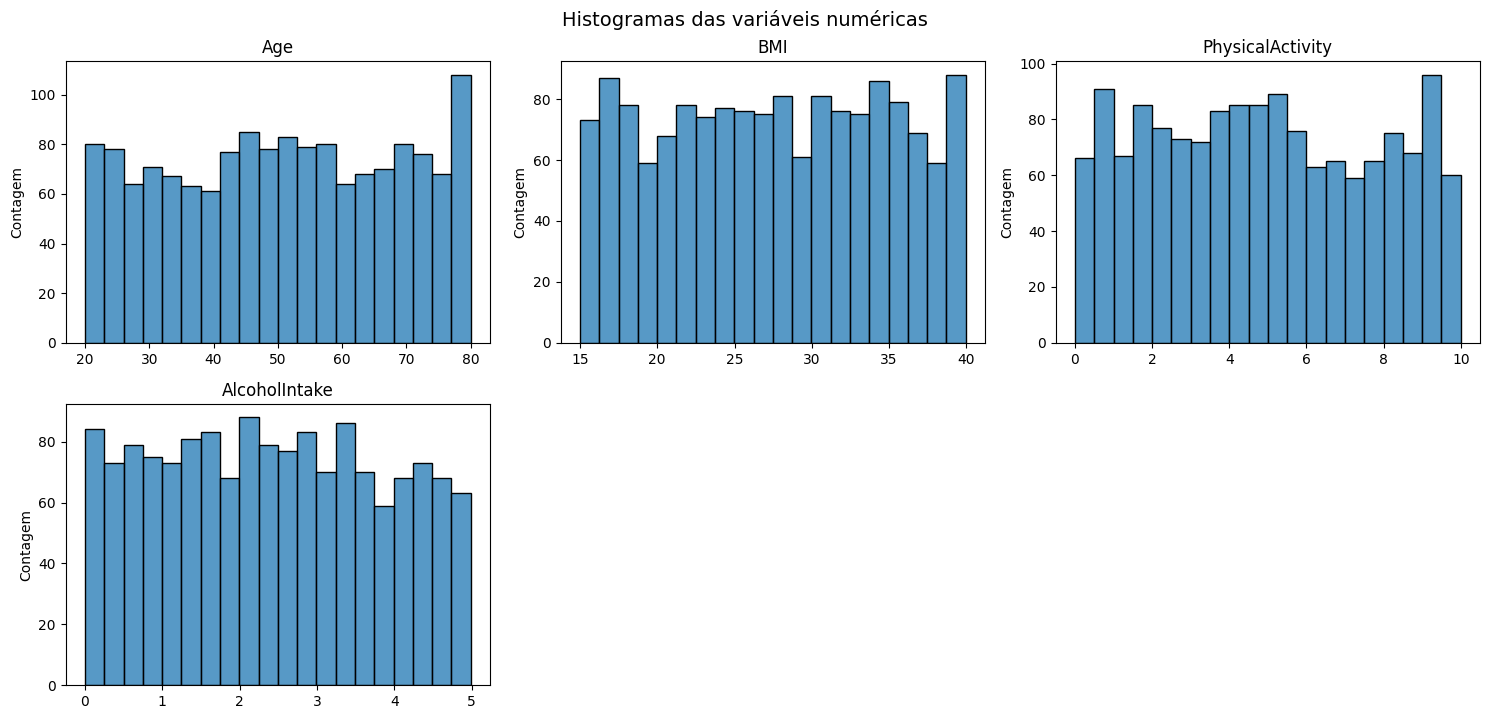

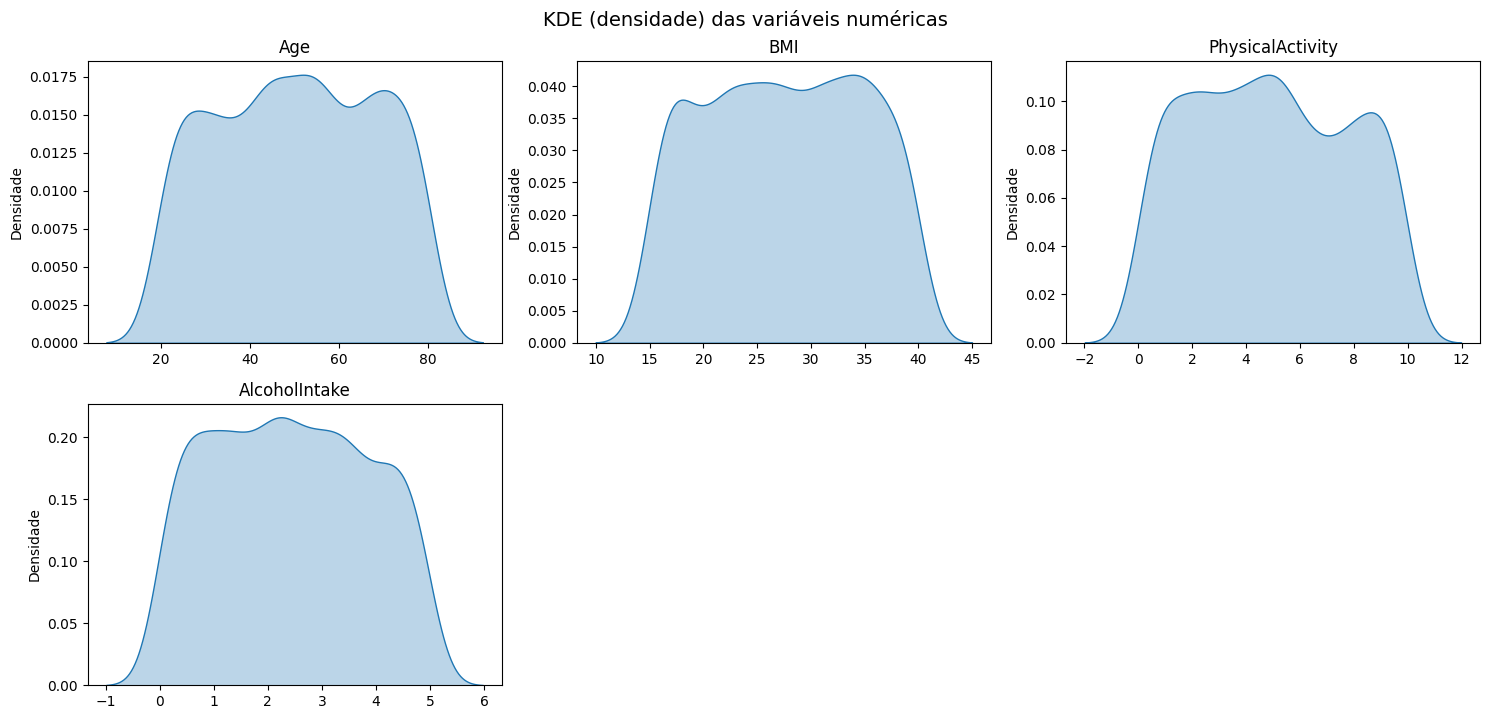

In [40]:
from pandas.api.types import is_numeric_dtype

# 1) Seleciona colunas numéricas com mais de 3 valores únicos
numeric_cols = [
    col for col in df.columns
    if is_numeric_dtype(df[col]) and df[col].nunique(dropna=True) > 3
]

if not numeric_cols:
    raise ValueError("Não há colunas numéricas com mais de 3 valores únicos para analisar.")

# 2) Estatísticas descritivas (apenas das colunas selecionadas)
stats = df[numeric_cols].describe()
print(stats)  # mostra no console / notebook

# 3) Histogramas (um subplot por variável, grid automático)
n = len(numeric_cols)
cols = 3                       # número de colunas no grid (ajuste se quiser)
rows = (n + cols - 1) // cols   # calcula linhas necessárias

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3.5))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    # dropna para evitar problemas com valores faltantes
    sns.histplot(df[col].dropna(), bins=20, kde=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Contagem')

# remove eixos sobrando caso haja
for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.suptitle('Histogramas das variáveis numéricas', y=1.02, fontsize=14)
plt.show()

# 4) Gráficos de densidade (KDE) — em subplots para evitar sobreposição
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3.5))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    # usar bandwidth automática; preenchimento leve para visualização
    sns.kdeplot(df[col].dropna(), ax=ax, fill=True, alpha=0.3)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Densidade')

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.suptitle('KDE (densidade) das variáveis numéricas', y=1.02, fontsize=14)
plt.show()

# ------**Construção do Modelo**--------

## 1. Divisão das variáveis em X e y

In [41]:
# 1) Separar features e alvo
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

## 2. Divisão em treino e teste

In [42]:
# Divisão treino (80%) e teste (20%), mantendo a mesma proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% dos dados ficam para teste
    random_state=42,     # garante reprodutibilidade da divisão
    stratify=y           # mantém a proporção de diagnóstico 0/1 nos dois conjuntos
)


## 3. Normalização dos dados

In [43]:
# Padroniza os dados (média 0, desvio 1)
scaler = StandardScaler()

# Ajusta no treino e transforma
X_train_scaled = scaler.fit_transform(X_train)

# Usa a mesma escala no teste
X_test_scaled = scaler.transform(X_test)

## 4. Escolha e Treinamento do Modelo

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Modelo de Regressão Logística
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)  # treina o modelo

# Modelo de Árvore de Decisão
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)        # treina o modelo

DecisionTreeClassifier(random_state=42)

## 5. Previsões

In [45]:
# Previsões do modelo de Regressão Logística
y_pred_log = log_model.predict(X_test_scaled)

# Previsões do modelo de Árvore de Decisão
y_pred_tree = tree_model.predict(X_test)

## 6. Avaliação das previsões

In [46]:
from sklearn.metrics import accuracy_score, classification_report

# Avaliação da Regressão Logística
print("Regressão Logística")
print(classification_report(y_test, y_pred_log))
print("Acurácia:", accuracy_score(y_test, y_pred_log))

# Avaliação da Árvore de Decisão
print("\nÁrvore de Decisão")
print(classification_report(y_test, y_pred_tree))
print("Acurácia:", accuracy_score(y_test, y_pred_tree))


Regressão Logística
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       189
           1       0.80      0.77      0.79       111

    accuracy                           0.84       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.84      0.84      0.84       300

Acurácia: 0.8433333333333334

Árvore de Decisão
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       189
           1       0.80      0.86      0.83       111

    accuracy                           0.87       300
   macro avg       0.85      0.86      0.86       300
weighted avg       0.87      0.87      0.87       300

Acurácia: 0.8666666666666667


7. Responda: Qual modelo obteve a melhor performance? Compare as métricas de precisão, recall, f1 score e acurácia para responder essa pergunta.

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calcula métricas dos dois modelos
metrics_log = {
    "accuracy": accuracy_score(y_test, y_pred_log),
    "precision": precision_score(y_test, y_pred_log, average='macro'),
    "recall": recall_score(y_test, y_pred_log, average='macro'),
    "f1": f1_score(y_test, y_pred_log, average='macro')
}

metrics_tree = {
    "accuracy": accuracy_score(y_test, y_pred_tree),
    "precision": precision_score(y_test, y_pred_tree, average='macro'),
    "recall": recall_score(y_test, y_pred_tree, average='macro'),
    "f1": f1_score(y_test, y_pred_tree, average='macro')
}

# Compara cada métrica
score_log = 0
score_tree = 0
melhores_metricas = []

for metric in metrics_log:
    if metrics_tree[metric] > metrics_log[metric]:
        score_tree += 1
        melhores_metricas.append(f"{metric} melhor na Árvore")
    elif metrics_log[metric] > metrics_tree[metric]:
        score_log += 1
        melhores_metricas.append(f"{metric} melhor na Regressão")

# Escolha final com justificativa
if score_tree > score_log:
    print("Melhor modelo: Árvore de Decisão")
    print("Motivo: apresentou melhores valores em:", ", ".join(melhores_metricas))
elif score_log > score_tree:
    print("Melhor modelo: Regressão Logística")
    print("Motivo: apresentou melhores valores em:", ", ".join(melhores_metricas))
else:
    print("Resultado: Empate")
    print("Motivo: cada modelo se destacou em métricas diferentes:", ", ".join(melhores_metricas))


Melhor modelo: Árvore de Decisão
Motivo: apresentou melhores valores em: accuracy melhor na Árvore, precision melhor na Árvore, recall melhor na Árvore, f1 melhor na Árvore


8. Agora teste rodar o modelo utilizando os parâmetros de "gini" e "entropy". Qual performou melhor?



In [48]:

# Treina árvore com critério 'entropy'
tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_entropy.fit(X_train, y_train)
y_pred_entropy = tree_entropy.predict(X_test)

# Treina árvore com critério 'gini'
tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_gini.fit(X_train, y_train)
y_pred_gini = tree_gini.predict(X_test)

# Função de avaliação simples
def avaliar(nome, y_true, y_pred):
    print(f"--- {nome} ---")
    print(classification_report(y_true, y_pred, digits=4))
    print("Acurácia:", round(accuracy_score(y_true, y_pred), 4))
    print()

# Mostrar resultados
avaliar("Árvore (Gini)", y_test, y_pred_gini)
avaliar("Árvore (Entropy)", y_test, y_pred_entropy)

# Determina o melhor critério pela acurácia
acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

if acc_gini > acc_entropy:
    print("Melhor critério: gini (maior acurácia)")
elif acc_entropy > acc_gini:
    print("Melhor critério: entropy (maior acurácia)")
else:
    print("Critérios empatados em acurácia")

--- Árvore (Gini) ---
              precision    recall  f1-score   support

           0     0.9116    0.8730    0.8919       189
           1     0.7983    0.8559    0.8261       111

    accuracy                         0.8667       300
   macro avg     0.8550    0.8644    0.8590       300
weighted avg     0.8697    0.8667    0.8675       300

Acurácia: 0.8667

--- Árvore (Entropy) ---
              precision    recall  f1-score   support

           0     0.9106    0.8624    0.8859       189
           1     0.7851    0.8559    0.8190       111

    accuracy                         0.8600       300
   macro avg     0.8479    0.8591    0.8524       300
weighted avg     0.8642    0.8600    0.8611       300

Acurácia: 0.86

Melhor critério: gini (maior acurácia)
